**LIBRERÍAS**

In [1]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import struct
import copy
import torch.nn.functional as F
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,precision_recall_curve)

**CARGA DEL DATASET**

In [2]:
url = "https://drive.google.com/drive/folders/1mdExsONP4S3b5Czn6nR4cLIdsZGs9zDQ"

gdown.download_folder(
    url,
    output="datasets",
    quiet=False,
    use_cookies=False)


Retrieving folder contents


Processing file 16NciaPpopHYrRp65-6nxihfENTD9h2An t10k-images.idx3-ubyte
Processing file 1YBjmRe5Xeqm-Bx0RPNXTXRjfcvCL9j9_ t10k-labels.idx1-ubyte
Processing file 1L-uWeLya6dEZdfpCZZSjVTTOFh6EPEBD train-images.idx3-ubyte
Processing file 1JkZqSVoh4Nkubq65AWdVc3VRFpquTTGQ train-labels.idx1-ubyte


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=16NciaPpopHYrRp65-6nxihfENTD9h2An
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\t10k-images.idx3-ubyte
100%|██████████| 7.84M/7.84M [00:00<00:00, 26.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YBjmRe5Xeqm-Bx0RPNXTXRjfcvCL9j9_
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\t10k-labels.idx1-ubyte
100%|██████████| 10.0k/10.0k [00:00<00:00, 2.47MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1L-uWeLya6dEZdfpCZZSjVTTOFh6EPEBD
From (redirected): https://drive.google.com/uc?id=1L-uWeLya6dEZdfpCZZSjVTTOFh6EPEBD&confirm=t&uuid=43cb7c99-8f62-45fe-8ef1-e9a6b77ac244
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\train-images.idx3-ubyte
100%|██████████| 47.0M/47.0M [00:01<00:00, 25.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JkZqSVoh4Nkubq65AWdVc3VRFpquTTGQ
To: 

['datasets\\t10k-images.idx3-ubyte',
 'datasets\\t10k-labels.idx1-ubyte',
 'datasets\\train-images.idx3-ubyte',
 'datasets\\train-labels.idx1-ubyte']

**EDA**

In [3]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Numero magico invalido: {magic}"
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
    return images

def load_mnist_labels(filepath):
    with open(filepath,'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Numero magico invalido: {magic}"
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

base_path = r"DATASETS-PROBLEMA2/"
X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

X_train, X_val, y_train, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train)

print(f"X_train: {X_train.shape}")  # (48000, 28, 28) o (48000, 784)
print(f"X_val:   {X_val.shape}")    # (12000, 28, 28) o (12000, 784)
print(f"X_test:  {X_test.shape}")   # (10000, 28, 28) o (10000, 784)

X_train: (48000, 28, 28)
X_val:   (12000, 28, 28)
X_test:  (10000, 28, 28)


In [4]:
datasets = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test,
}

print(" Conteo de NaNs por Dataset ")
for name, data in datasets.items():
    n_nans = np.isnan(data).sum()
    print(f"{name}: {n_nans} valores NaN (Shape: {data.shape})")

 Conteo de NaNs por Dataset 
X_train: 0 valores NaN (Shape: (48000, 28, 28))
y_train: 0 valores NaN (Shape: (48000,))
X_val: 0 valores NaN (Shape: (12000, 28, 28))
y_val: 0 valores NaN (Shape: (12000,))
X_test: 0 valores NaN (Shape: (10000, 28, 28))
y_test: 0 valores NaN (Shape: (10000,))


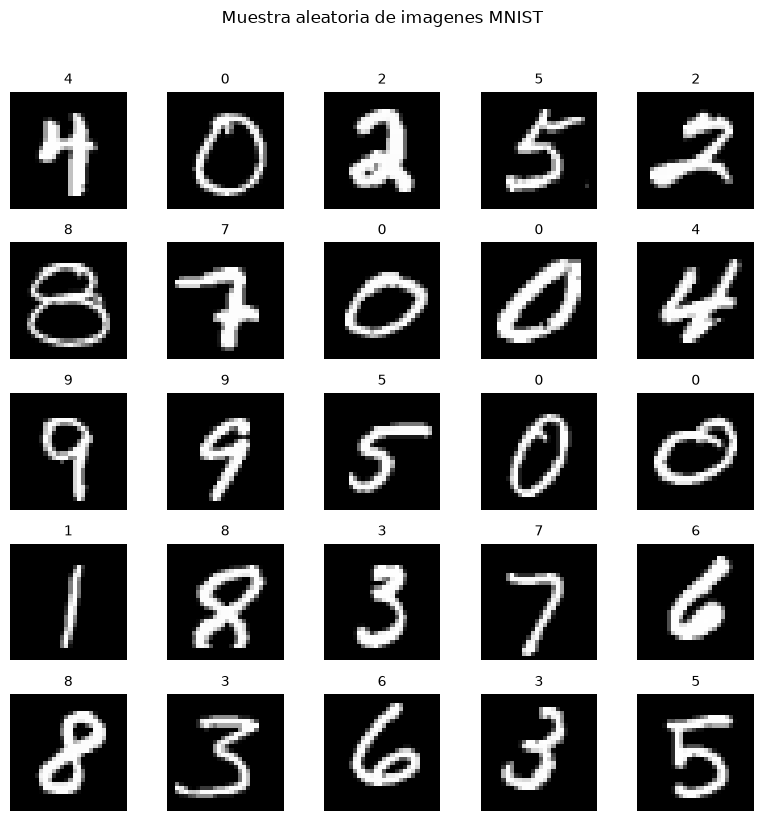

In [5]:
indices = np.random.choice(len(X_train), 25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
df_porcentajes = pd.DataFrame({
    "Train (%)": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "Val (%)":   pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "Test (%)":  pd.Series(y_test).value_counts(normalize=True).sort_index() * 100,})

df_conteos = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts().sort_index(),
    "Val":   pd.Series(y_val).value_counts().sort_index(),
    "Test":  pd.Series(y_test).value_counts().sort_index(),})

print("=== Conteo Absoluto por Clase ===")
print(df_conteos)

print("\n=== Porcentaje por Clase (%) ===")
print(df_porcentajes.round(2))

=== Conteo Absoluto por Clase ===
   Train   Val  Test
0   4738  1185   980
1   5394  1348  1135
2   4766  1192  1032
3   4905  1226  1010
4   4674  1168   982
5   4337  1084   892
6   4734  1184   958
7   5012  1253  1028
8   4681  1170   974
9   4759  1190  1009

=== Porcentaje por Clase (%) ===
   Train (%)  Val (%)  Test (%)
0       9.87     9.88      9.80
1      11.24    11.23     11.35
2       9.93     9.93     10.32
3      10.22    10.22     10.10
4       9.74     9.73      9.82
5       9.04     9.03      8.92
6       9.86     9.87      9.58
7      10.44    10.44     10.28
8       9.75     9.75      9.74
9       9.91     9.92     10.09


**PREPROCESAMIENTO - APLANADO Y NORMALIZACIÓN**

In [7]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") 
print(f"X_val_flat:   {X_val_flat.shape}")
print(f"X_test_flat:  {X_test_flat.shape}")

X_train_flat = X_train_flat.astype(np.float32) / 255.0
X_val_flat   = X_val_flat.astype(np.float32) / 255.0
X_test_flat  = X_test_flat.astype(np.float32) / 255.0

X_train_flat: (48000, 784)
X_val_flat:   (12000, 784)
X_test_flat:  (10000, 784)


In [8]:
df_train = pd.DataFrame(X_train_flat)

df_train['label'] = y_train

print("--- INFO ---")
df_train.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Columns: 785 entries, 0 to label
dtypes: float32(784), uint8(1)
memory usage: 143.6 MB


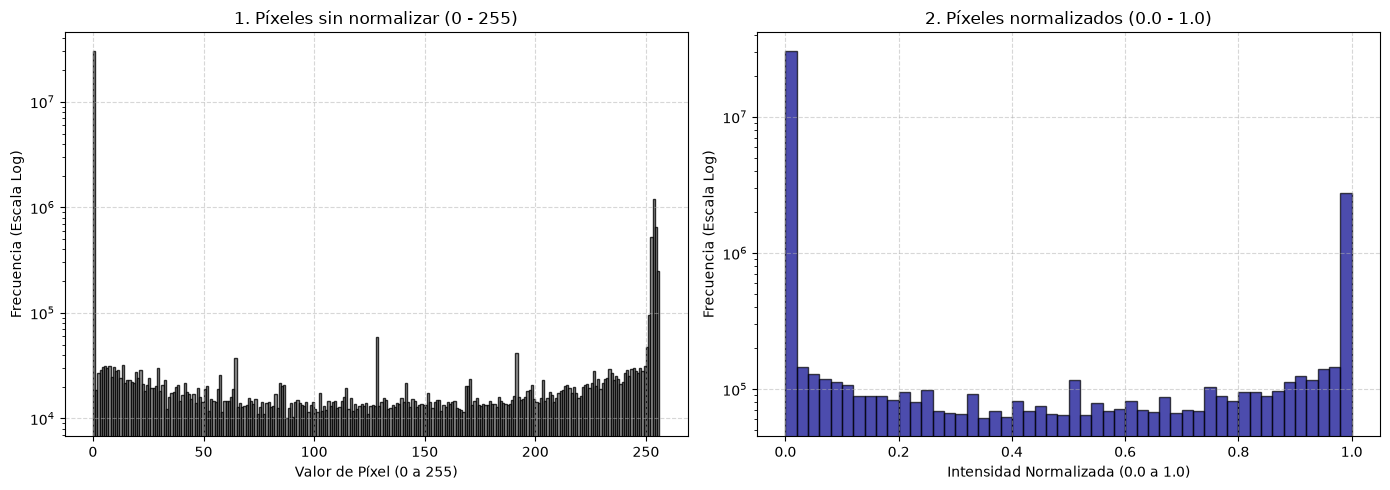

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train.ravel(), bins=256, range=(0, 256), color='gray', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title("1. Píxeles sin normalizar (0 - 255)")
axes[0].set_xlabel("Valor de Píxel (0 a 255)")
axes[0].set_ylabel("Frecuencia (Escala Log)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(X_train_flat.ravel(), bins=50, color='darkblue', edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title("2. Píxeles normalizados (0.0 - 1.0)")
axes[1].set_xlabel("Intensidad Normalizada (0.0 a 1.0)")
axes[1].set_ylabel("Frecuencia (Escala Log)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**  **

**MLP**

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        out = self.dropout(self.relu(self.fc1(x)))
        out = self.dropout(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

In [11]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)  
 
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


In [12]:
X_train_t = torch.as_tensor(X_train_flat, dtype=torch.float32)
y_train_t = torch.as_tensor(y_train, dtype=torch.long)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)


X_val_t = torch.as_tensor(X_val_flat, dtype=torch.float32)
y_val_t = torch.as_tensor(y_val, dtype=torch.long)
val_ds = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)


X_test_t = torch.as_tensor(X_test_flat, dtype=torch.float32)
y_test_t = torch.as_tensor(y_test, dtype=torch.long)
test_ds = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

C:\Users\fjm25\AppData\Local\Temp\ipykernel_15800\971536808.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_test_t = torch.as_tensor(y_test, dtype=torch.long)


Epoch 01/30 | Train Loss: 0.5151 - Train Acc: 0.845 | Val Loss: 0.2087 - Val Acc: 0.938 | LR: 0.001000
Epoch 02/30 | Train Loss: 0.2430 - Train Acc: 0.929 | Val Loss: 0.1477 - Val Acc: 0.955 | LR: 0.001000
Epoch 03/30 | Train Loss: 0.1892 - Train Acc: 0.944 | Val Loss: 0.1280 - Val Acc: 0.961 | LR: 0.001000
Epoch 04/30 | Train Loss: 0.1589 - Train Acc: 0.953 | Val Loss: 0.1120 - Val Acc: 0.966 | LR: 0.001000
Epoch 05/30 | Train Loss: 0.1423 - Train Acc: 0.957 | Val Loss: 0.1016 - Val Acc: 0.968 | LR: 0.001000
Epoch 06/30 | Train Loss: 0.1262 - Train Acc: 0.962 | Val Loss: 0.0988 - Val Acc: 0.972 | LR: 0.001000
Epoch 07/30 | Train Loss: 0.1145 - Train Acc: 0.965 | Val Loss: 0.0976 - Val Acc: 0.972 | LR: 0.001000
Epoch 08/30 | Train Loss: 0.1114 - Train Acc: 0.966 | Val Loss: 0.0916 - Val Acc: 0.974 | LR: 0.001000
Epoch 09/30 | Train Loss: 0.1003 - Train Acc: 0.969 | Val Loss: 0.0900 - Val Acc: 0.974 | LR: 0.001000
Epoch 10/30 | Train Loss: 0.0995 - Train Acc: 0.970 | Val Loss: 0.0885 - 

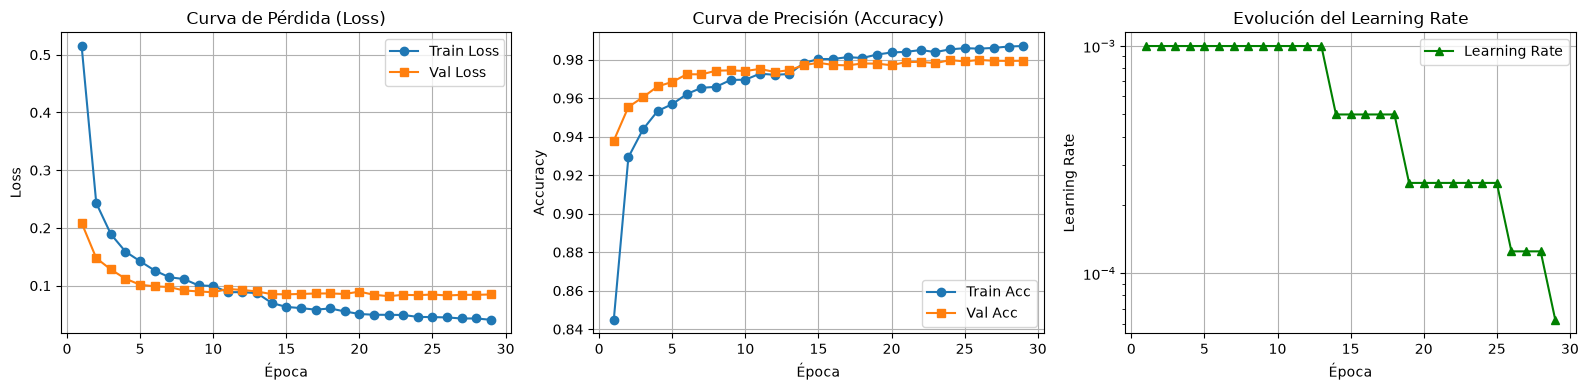

In [13]:
IN_FEATURES = 784
N_CLASSES = 10

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP(input_dim=IN_FEATURES,
    hidden_dim1=128,
    hidden_dim2=64,
    output_dim=N_CLASSES,
    dropout_rate=0.3,).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.5,patience=2,)

patience_es = 7        
patience_counter = 0
best_val_loss = float("inf")
best_model_weights = None

train_losses, train_accs = [], []
val_losses, val_accs = [], []
lr_history = []

epochs = 30
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

            _, preds = torch.max(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_acc = val_correct / val_total
    avg_val_loss = val_loss / val_total

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    scheduler.step(avg_val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.3f} | "
          f"Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.3f} | "
          f"LR: {current_lr:.6f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "best_model.pt") 
        patience_counter = 0 
    else:
        patience_counter += 1
        if patience_counter >= patience_es:
            print(f"\n[Early Stopping] Se detuvo en la época {epoch + 1} por falta de mejora en val_loss.")
            break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n✓ Se cargaron los pesos del mejor checkpoint en el modelo.")

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)

        test_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
avg_test_loss = test_loss / total

print("\n" + "=" * 50)
print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {accuracy * 100:.2f}%")
print("=" * 50 + "\n")

epochs_ran = len(train_losses)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, epochs_ran + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, epochs_ran + 1), val_losses, label="Val Loss", marker="s")
plt.title("Curva de Pérdida (Loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs_ran + 1), train_accs, label="Train Acc", marker="o")
plt.plot(range(1, epochs_ran + 1), val_accs, label="Val Acc", marker="s")
plt.title("Curva de Precisión (Accuracy)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs_ran + 1), lr_history, label="Learning Rate", color="green", marker="^")
plt.title("Evolución del Learning Rate")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**TEST**

Se cargaron los mejores pesos de validación (memoria).

Test Loss: 0.0824 | Accuracy Global: 97.87%

 Accuracy de cada Clase
Clase 0: 99.18%
Clase 1: 98.77%
Clase 2: 97.87%
Clase 3: 98.51%
Clase 4: 97.56%
Clase 5: 97.76%
Clase 6: 97.91%
Clase 7: 97.57%
Clase 8: 96.51%
Clase 9: 96.93%

 Reporte 
              precision    recall  f1-score   support

           0     0.9789    0.9918    0.9853       980
           1     0.9885    0.9877    0.9881      1135
           2     0.9749    0.9787    0.9768      1032
           3     0.9698    0.9851    0.9774      1010
           4     0.9785    0.9756    0.9771       982
           5     0.9820    0.9776    0.9798       892
           6     0.9832    0.9791    0.9812       958
           7     0.9728    0.9757    0.9743      1028
           8     0.9771    0.9651    0.9711       974
           9     0.9809    0.9693    0.9751      1009

    accuracy                         0.9787     10000
   macro avg     0.9787    0.9786    0.9786     10000


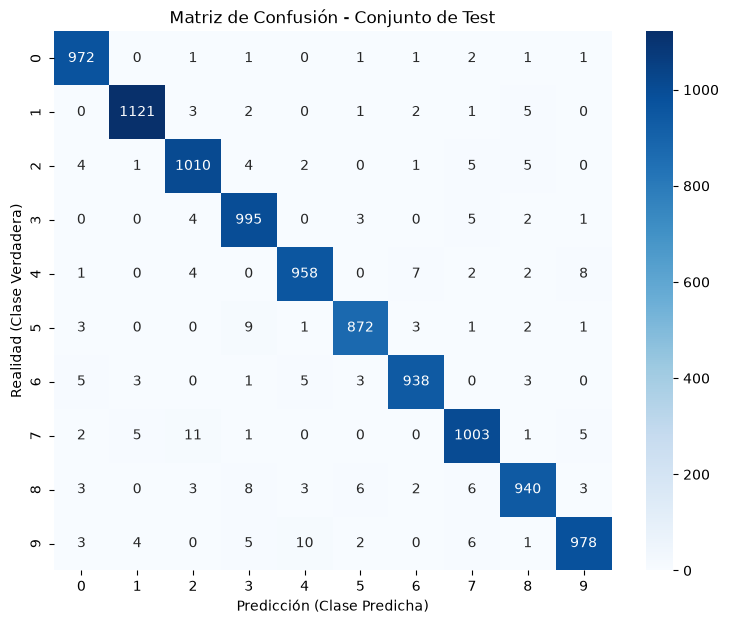


 PARES DE DÍGITOS CON MAYOR CONFUSIÓN
Real     | Predicho   | Cantidad de Errores
------------------------------------------
Dígito 7  | Dígito 2    | 11 errores
Dígito 9  | Dígito 4    | 10 errores
Dígito 5  | Dígito 3    | 9 errores
Dígito 4  | Dígito 9    | 8 errores
Dígito 8  | Dígito 3    | 8 errores


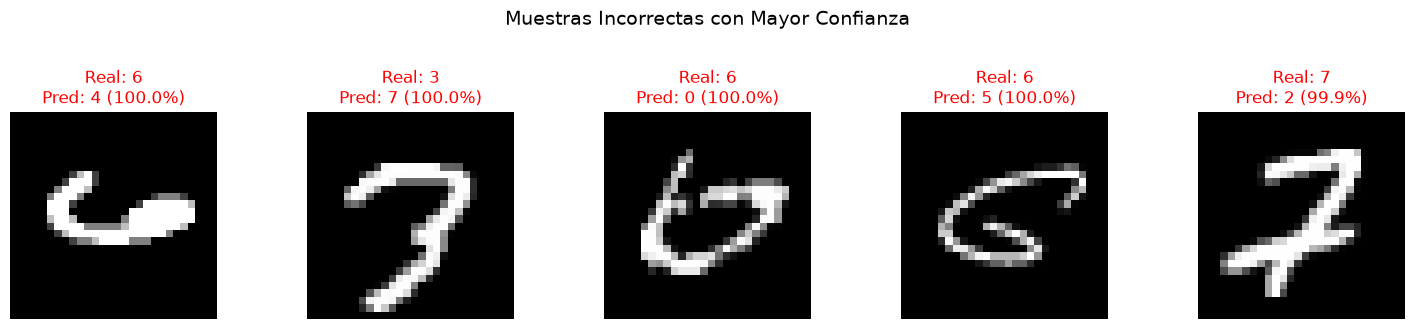

In [15]:
if "best_model_weights" in locals() and best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("Se cargaron los mejores pesos de validación (memoria).")
elif torch.os.path.exists("best_model.pt"):
    model.load_state_dict(torch.load("best_model.pt"))
    print("Se cargaron los mejores pesos desde 'best_model.pt'.")

model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_targets = []
all_probs = []
all_images = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch_dev, y_batch_dev = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch_dev)
        loss = loss_fn(outputs, y_batch_dev)

        test_loss += loss.item() * X_batch.size(0)

        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        correct += (preds == y_batch_dev).sum().item()
        total += y_batch_dev.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch_dev.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())
        all_images.extend(X_batch.numpy())

accuracy = correct / total
avg_test_loss = test_loss / total

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)
all_images = np.array(all_images)

print("\n" + "=" * 50)
print(f"Test Loss: {avg_test_loss:.4f} | Accuracy Global: {accuracy * 100:.2f}%")
print("=" * 50 + "\n")

cm = confusion_matrix(all_targets, all_preds)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

print(" Accuracy de cada Clase")
for cls, acc in enumerate(class_accuracies):
    print(f"Clase {cls}: {acc * 100:.2f}%")

print("\n Reporte ")
print(classification_report(all_targets, all_preds, digits=4))

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.title("Matriz de Confusión - Conjunto de Test")
plt.xlabel("Predicción (Clase Predicha)")
plt.ylabel("Realidad (Clase Verdadera)")
plt.show()

confusions = []
for true_class in range(10):
    for pred_class in range(10):
        if true_class != pred_class:
            count = cm[true_class, pred_class]
            if count > 0:
                confusions.append((true_class, pred_class, count))

confusions.sort(key=lambda x: x[2], reverse=True)

print("\n PARES DE DÍGITOS CON MAYOR CONFUSIÓN")
print(f"{'Real':<8} | {'Predicho':<10} | {'Cantidad de Errores':<18}")
print("-" * 42)
for true_c, pred_c, count in confusions[:5]:
    print(f"Dígito {true_c:<2} | Dígito {pred_c:<4} | {count} errores")

incorrect_mask = (all_preds != all_targets)
incorrect_indices = np.where(incorrect_mask)[0]
incorrect_probs = all_probs[incorrect_mask]

top_confident_error_indices = incorrect_indices[np.argsort(incorrect_probs)[::-1][:5]]

plt.figure(figsize=(15, 3))
for i, idx in enumerate(top_confident_error_indices):
    img = all_images[idx]
    
    if img.ndim == 1 or img.shape[0] == 784:
        img = img.reshape(28, 28)
    elif img.ndim == 3 and img.shape[0] == 1:
        img = img.squeeze(0)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Real: {all_targets[idx]}\nPred: {all_preds[idx]} ({all_probs[idx]*100:.1f}%)", color="red")
    plt.axis("off")

plt.suptitle("Muestras Incorrectas con Mayor Confianza", fontsize=14, y=1.08)
plt.tight_layout()
plt.show()

**OVERFITTING**
Sobreajuste leve. Las curvas de pérdida se cruzan alrededor de la época 12; a partir de ahí la pérdida de entrenamiento continúa descendiendo (~0.04) mientras que la de validación se estabiliza (~0.085). La brecha de accuracy es inferior a 1 punto porcentual (0.987 en entrenamiento frente a 0.980 en validación). Este comportamiento indica un ajuste leve al conjunto de entrenamiento, pero no un sobreajuste severo: la pérdida de validación no aumenta y la accuracy de validación no disminuye. La evaluación final en el conjunto de test (accuracy 97.78%, loss 0.0748) es consistente con la validación, lo que confirma que el modelo generaliza adecuadamente. Se aplicaron dropout (0.3), ReduceLROnPlateau y early stopping para controlarlo.